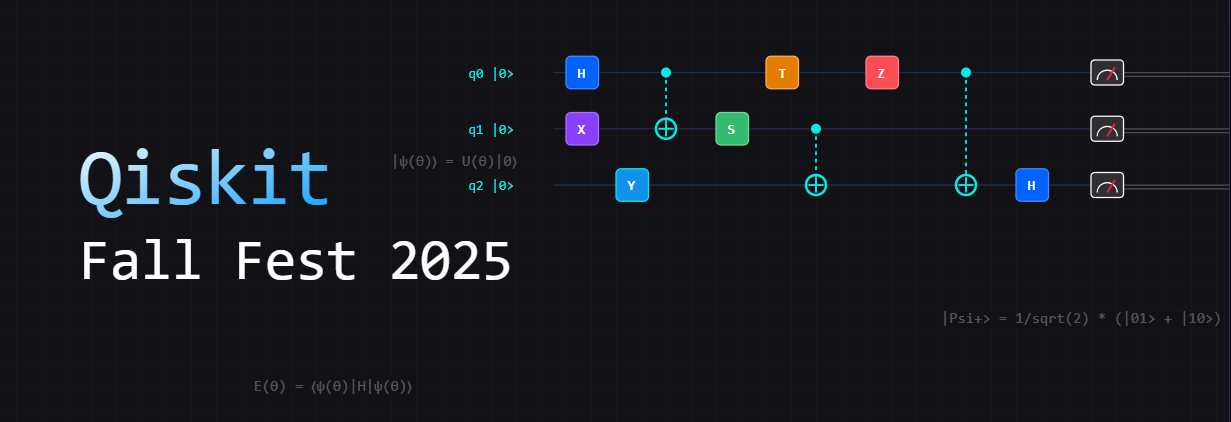

# Qiskit Fundamentals Lab

Welcome to the Qiskit 2 Fundamentals Lab! This notebook is designed to help get up to speed on Qiskit 2 fundamentals by providing hands-on exercises for 18 core concepts.

**Instructions:**
1. Read the explanation for each concept.
2. Complete the coding exercise in the designated cell.
3. After attempting the exercise, you can check your answer in the _solutions notebook

## Setup

First, let's install and import the necessary libraries. Run the cells below.

In [ ]:
%pip install qiskit[visualization] qiskit-ibm-runtime qiskit-aer qiskit_qasm3_import

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit_aer import AerSimulator
from qiskit.circuit import Parameter, ParameterVector
import qiskit.qasm3
from qiskit_ibm_runtime.fake_provider import FakeVigoV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler, EstimatorV2 as Estimator, QiskitRuntimeService
from qiskit.primitives import BackendSamplerV2
from qiskit.primitives import BackendEstimatorV2 as Estimator

## 1. Pauli Operators (Single-Qubit Operators)

**Explanation:** The Pauli operators (X, Y, Z, and I) are 2x2 matrices that represent fundamental single-qubit quantum operations. In Qiskit, these can be created using the `Pauli` class (e.g., `Pauli('X')` for the X operator). You can also construct multi-qubit Paulis by specifying characters for each qubit (e.g., `'XI'` for identity on qubit 0 and X on qubit 1, following Qiskit's little-endian bit ordering).

**Exercise 1:**
Write code that performs following functionality:
1. Creates a 3-qubit Pauli operator representing `Z` on qubit 2, `Y` on qubit 1, and `I` (Identity) on qubit 0.
2. Prints the operator.
3. Prints its corresponding matrix representation

In [3]:
# Your code here
pauli_op = Pauli('ZYI')
print(pauli_op)
print(pauli_op.to_matrix())

ZYI
[[0.+0.j 0.+0.j 0.-1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.-1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+1.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+1.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.-1.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.-1.j 0.+0.j 0.+0.j]]


## 2. Single-Qubit Gates and Phases

**Explanation:** Single-qubit gates like X, Y, Z, H, S, and T are basic operations on one qubit. S and T are phase gates. The S-gate adds a π/2 phase to the |1⟩ component of any quantum state, while the T-gate adds a π/4 phase to the |1⟩ component, leaving the |0⟩ component unchanged in both cases. These phase shifts are crucial for many quantum algorithms.

**Exercise 2:**
Write code that performs following functionality:
1. Creates a quantum circuit that contains one qubit.
2. Puts the qubit in the state |1⟩.
3. Adds a single gate to the circuit that applies a π/4 phase shift to the qubit.
4. Output a Dirac notation representation of the circuit's statevector.

In [4]:
# Your code here
# 1. Initialize a 1-qubit circuit
qc = QuantumCircuit(1)

# 2. Flip qubit from |0⟩ to |1⟩
qc.x(0)

# 3. Apply π/4 phase shift
qc.p(np.pi / 4, 0)
#qc.t(0)- another solution

# 4. Get the statevector
statevector = Statevector(qc)

# 5. Output in Dirac notation
statevector.draw('latex', prefix='Statevector: ')

<IPython.core.display.Latex object>

## 3. Superposition and Bloch Sphere Rotations

**Explanation:** Gates like `RX`, `RY`, and `RZ` perform rotations around the axes of the Bloch sphere, creating superposition states. A rotation by an angle θ around the Y-axis (`RY(θ)`) on an initial state |0⟩ produces the superposition cos(θ/2)|0⟩ + sin(θ/2)|1⟩. The probabilities of measuring 0 or 1 are the squares of these amplitudes.

**Exercise 3:**
Write code that performs following functionality:
1. Creates a quantum circuit that contains one qubit.
2. Applies a single gate to qubit 0 (initially in state |0⟩) to create a superposition where the probability of measuring |0⟩ is approximately 14.6% and the probability of measuring |1⟩ is 85.4%.
3. Prints the probabilities.
4. Displays a Bloch sphere representation of the statevector.

Probabilities: {np.str_('0'): np.float64(0.146), np.str_('1'): np.float64(0.854)}


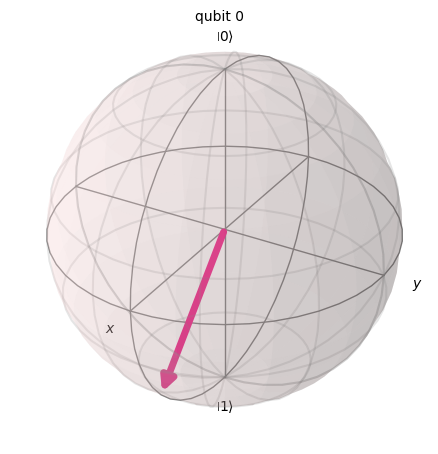

In [5]:
# Your code here
# 1. Initialize a 1-qubit circuit
qc = QuantumCircuit(1)

# 2. Calculate theta for the RY gate
# cos^2(theta/2) = 0.146 -> theta = 2 * arccos(sqrt(0.146))
p0 = 0.146
theta = 2 * np.arccos(np.sqrt(p0))

# 3. Apply RY rotation gate to qubit 0
qc.ry(theta, 0)

# 4. Get the statevector and compute probabilities
state = Statevector.from_instruction(qc)
probs = state.probabilities_dict()

# 5. Print the probabilities
print(f"Probabilities: {probs}")

# 6. Display Bloch sphere
plot_bloch_multivector(state)


## 4. Multi-Qubit Operations and Entanglement

**Explanation:** Multi-qubit gates like the CNOT (`qc.cx(control, target)`) create entanglement when applied to superposition states. A common entangled state is the Bell state |Φ+⟩ = 1/√2(|00⟩ + |11⟩), created by applying a Hadamard gate to one qubit and then a CNOT gate. Remember Qiskit's bit ordering: qubit 0 is the rightmost bit (least significant).

**Exercise 4:**
Write code that performs following functionality:
1. Creates a quantum circuit that contains two qubits.
2. Create the Bell state |Φ+⟩ in which the first qubit (q0) is the control qubit.
3. Draws the quantum circuit using matplotlib.
4. Prints the circuit's statevector.

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


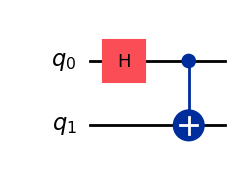

In [6]:
# Your code here
# 1. Initialize a 2-qubit circuit (initialized to |00⟩)
qc = QuantumCircuit(2)

# 2. Put qubit 0 into superposition
qc.h(0)

# 3. Entangle qubit 0 (control) and qubit 1 (target)
qc.cx(0, 1)

# 4. Print the circuit's statevector
statevector = Statevector(qc)
print(statevector)

# 5. Draw the quantum circuit using matplotlib
display(qc.draw('mpl'))

## 5. Building Quantum Circuits and Drawing

**Explanation:** The `QuantumCircuit` class is used to build circuits. The `draw()` method provides visualizations in formats like `'text'`, `'mpl'`, and `'latex'`. You can customize the drawing with parameters such as `reverse_bits` to flip the qubit order.

**Exercise 5:**
Write code that performs following functionality:
1. Creates a 3-qubit GHZ state.
2. Draws the circuit with the qubit order reversed in the diagram (q2 on top, q0 on bottom).


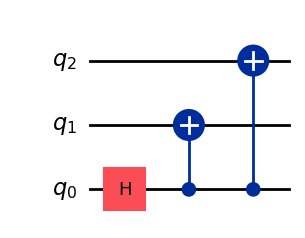

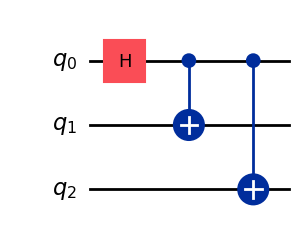

In [7]:
# Your code here
# 1. Initialize a 3-qubit circuit
qc = QuantumCircuit(3)

# 2. Put qubit 0 into superposition
qc.h(0)

# 3. Entangle qubit 0 with qubit 1
qc.cx(0, 1)

# 4. Entangle qubit 1 with qubit 2
qc.cx(0, 2)

# 5. Draw the circuit with the qubit order reversed (q2 on top)
display(qc.draw("mpl", reverse_bits=True))

# 6. Draw the circuit with the qubit order (q0 on top)
display(qc.draw("mpl", reverse_bits=False))

## 6. Dynamic Circuits and Classical Control Flow

**Explanation:** Qiskit supports dynamic circuits where operations can be conditioned on classical measurement outcomes. The `if_test()` context manager can be used to create conditional blocks where operations are executed based on classical bit values. This allows for powerful classical feed-forward in your quantum programs.

**Exercise 6:**
Write code that performs following functionality:
1. Creates a quantum circuit that contains two qubits and at least one classical bit.
2. Adds a hadamard gate to the least significant qubit
3. Applies an X gate to qubit 1 *only if* a measurement of qubit 0 yields the result `1`. Use the `if_test()` context manager with the appropriate condition tuple.
4. Draws the circuit using matplotlib.

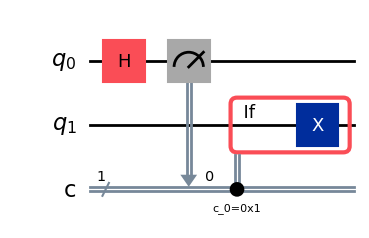

In [8]:
# Your code here
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

# Create registers
# Qubit 0 is the least significant qubit (LSB) in Qiskit's ordering
qr = QuantumRegister(2, name="q")
cr = ClassicalRegister(1, name="c")
qc = QuantumCircuit(qr, cr)

# Add a Hadamard gate to the least significant qubit (qubit 0)
qc.h(0)

# Measure qubit 0 into the classical bit
qc.measure(0, 0)

# Apply X gate to qubit 1 if the measurement of qubit 0 yields 1
# The condition tuple format is (classical_register_or_bit, target_value)
with qc.if_test((cr[0], 1)):
    qc.x(1)

# Draw the circuit using matplotlib
display(qc.draw(output="mpl"))

## 7. Visualizing Quantum States and Results

**Explanation:** Qiskit offers several functions to visualize results. `plot_histogram(counts)` is used to display measurement outcomes from a simulation or real device run. You can sort the results for easier analysis, for example, by the frequency of the outcomes.

**Exercise 7:**
Write code that performs following functionality:
1. Creates a quantum circuit that contains the |Φ+⟩ Bell state.
2. Measures the results on classical wires.
3. Runs the circuit using the `AerSimulator`.
4. Gets the measurement counts.
5. Plots a histogram with the bars sorted from the most common outcome to the least common.

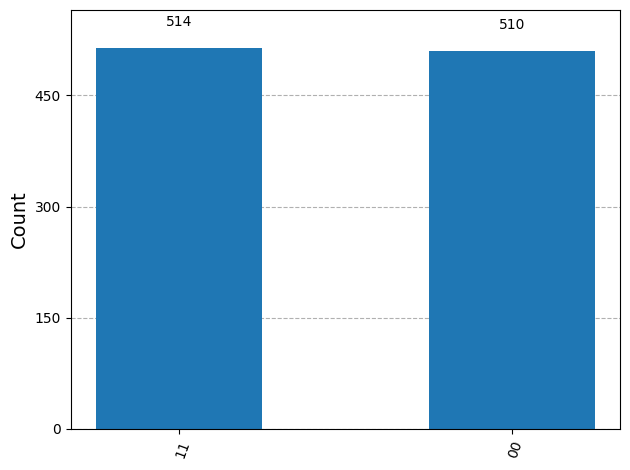

In [10]:
# Your code here
# 1. Create a quantum circuit with 2 qubits and 2 classical bits
qc = QuantumCircuit(2, 2)

# 2. Build the |Φ+⟩ Bell state
qc.h(0)          # Apply Hadamard gate to qubit 0
qc.cx(0, 1)      # Apply CNOT gate with qubit 0 as control and qubit 1 as target

# 3. Measure the results onto the classical wires
qc.measure([0, 1], [0, 1])

# 4. Initialize the AerSimulator and transpile the circuit
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)

# 5. Run the circuit and get the measurement counts
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts()

# 6. Plot the histogram sorted from most common to least common outcome
# 'desc' sorts the bars by value in descending order (highest count first)
plot_histogram(counts, sort='desc')


## 8. Parameterized Quantum Circuits

**Explanation:** Qiskit allows circuits with symbolic parameters using the `Parameter` class. These parameters act as placeholders that can be bound to specific numerical values later using the `assign_parameters()` method. This is fundamental for variational algorithms like VQE and QAOA.

**Exercise 8:**
Write code that performs following functionality:
1. Creates a `Parameter` instance to represent a parameter named `theta`.
2. Creates a quantum circuit `qc` that contains one qubit.
3. Adds an RX gate with parameter `theta` to the qubit wire.
4. Draws the `qc` circuit.
5. Creates a new circuit `bound_qc` by binding the parameter `theta` to the value `π/2`.
6. Draws the `bound_qc` circuit.

Parameterized Circuit (qc):


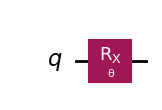


Bound Circuit (bound_qc):


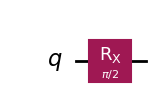

In [11]:
# Your code here
# 1. Create a Parameter instance named theta
theta = Parameter("θ")

# 2. Create a quantum circuit with one qubit
qc = QuantumCircuit(1)

# 3. Add an RX gate with parameter theta to qubit 0
qc.rx(theta, 0)

# 4. Draw the parameterized circuit
print("Parameterized Circuit (qc):")
display(qc.draw(output="mpl"))
plt.show()

# 5. Create a new circuit by binding theta to π/2
# We use assign_parameters() to bind the values
bound_qc = qc.assign_parameters({theta: np.pi / 2})

# 6. Draw the bound circuit
print("\nBound Circuit (bound_qc):")
display(bound_qc.draw(output="mpl"))

## 9. Circuit Transpilation and Optimization

**Explanation:** Transpilation adapts a quantum circuit to the constraints of a specific quantum device, including its basis gates and qubit connectivity. The `generate_preset_pass_manager()` function creates a transpilation pass manager with preset configurations. It has several `optimization_level` settings (0-3), where higher levels apply more advanced optimization techniques to reduce circuit depth and gate count, at the cost of longer compilation time.

**Exercise 9:**
Write code that performs following functionality:
1. Creates a 3-qubit GHZ circuit.
2. Transpiles the circuit for the `FakeVigoV2` backend, using the highest level of optimization (level 3).
3. Prints the depth of the original circuit.
4. Prints the depth of the transpiled circuit.
5. Draws the transpiled circuit.

Original circuit depth: 3
Transpiled circuit depth: 5


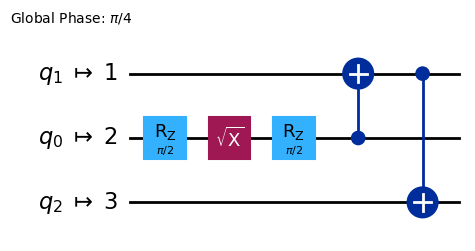

In [12]:
# Your code here
# 1. Create a 3-qubit GHZ circuit
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)

# 2. Instantiate the fake backend
backend = FakeVigoV2()

# 3. Transpile the circuit using optimization level 3
# Level 3 applies the highest level of noise and gate reduction optimizations
transpiled_qc = transpile(qc, backend=backend, optimization_level=3)

# 4. Print the depth of the original circuit
print(f"Original circuit depth: {qc.depth()}")

# 5. Print the depth of the transpiled circuit
print(f"Transpiled circuit depth: {transpiled_qc.depth()}")

# 6. Draw the transpiled circuit using matplotlib
display(transpiled_qc.draw(output="mpl"))

## 10. Qiskit Runtime Execution Modes

**Explanation:** Qiskit Runtime offers three execution modes: **job**, **session**, and **batch**. The execution modes determine how your jobs are scheduled, and choosing the right execution mode allows your workload to run efficiently within your budget.

**Exercise 10:** This is a conceptual question. In the markdown cell below, explain which execution mode (job, session, or batch) you would use for a Variational Quantum Eigensolver (VQE) algorithm and briefly state why.

*[Your answer here]*

For a Variational Quantum Eigensolver (VQE) algorithm, you should use the Session execution mode.
### Why use Session Mode

* **Iterative Design**: VQE is a hybrid quantum-classical algorithm. It requires hundreds or thousands of rapid, back-and-forth loops between the classical optimizer and the quantum processing unit (QPU).
* **Minimized Latency**: In Job mode, every single iteration is forced to wait at the back of the public queue, causing a standard VQE run to take hours or days. Session mode locks down the QPU for your algorithm. This allows successive iterations to bypass the public scheduling queue entirely.
* **Cost and Efficiency**: By prioritizing your job sequence back-to-back, a Session ensures the classical optimizer receives runtime data immediately. This completes your VQE training loop in the shortest time possible before the session context expires.
* **Distinction from Batch**: While Batch mode also bypasses queue latency for multiple jobs, it handles independent tasks that can be submitted all at once. Because VQE requires the results of iteration $N$ to calculate the parameters for iteration $N+1$, you cannot submit them concurrently. You must use a dynamic Session.

## 11. Quantum Primitives (Sampler and Estimator)

**Explanation:** Primitives are high-level interfaces for common quantum tasks. The **Sampler** and **Estimator** are two key primitives that each serve different purposes when working with quantum circuits. They abstract away the details of execution and error mitigation, making it easier to extract meaningful information from quantum computations.

**Exercise 11:** This is a conceptual question. In the markdown cell below, describe the fundamental difference between the Sampler and Estimator primitives in a single sentence.

*[Your answer here]*

The fundamental difference is that the **Sampler** calculates the probability distribution of distinct binary bitstrings from measurement outputs, whereas the **Estimator** calculates the expected value of an operator (observable) over a given quantum state. For more in depth leraning please use this material
[Introduction to primitives](https://quantum.cloud.ibm.com/docs/en/guides/primitives) [Sampler quickstart](https://quantum.cloud.ibm.com/docs/en/guides/get-started-with-sampler) [Estimator quickstart](https://qiskit.qotlabs.org/docs/guides/get-started-with-estimator)

## 12. Using the Sampler Primitive

**Explanation:** In Qiskit 2, you can use the `Sampler` primitive from `qiskit_ibm_runtime` with local simulators like `AerSimulator`. Here you'll initialize a `Sampler` with a backend mode, transpile your circuit using `generate_preset_pass_manager`, then use the `.run([circuits], shots=...)` method. The result object contains measurement data accessible via the classical register names.

**Exercise 12:**
Write code that performs following functionality:
1. Creates a quantum circuit that contains the |Φ+⟩ Bell state.
2. Uses the `measure_all` method to measure the results.
3. Transpiles the circuit using the `AerSimulator` backend.
4. Initializes the `Sampler` primitive with the `AerSimulator` backend
5. Runs the Sampler.
6. Gets the measurement counts.
7. Prints the measurement counts.


In [13]:
# Your code here
# 1. Create a quantum circuit that contains the |Φ+⟩ Bell state
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

# 2. Use the measure_all method to measure the results
# This automatically handles classical register creation and places a barrier
qc.measure_all()

# 3. Transpile the circuit using the AerSimulator backend
backend = AerSimulator()
transpiled_qc = transpile(qc, backend=backend)

# 4. Initialize the Sampler primitive with the AerSimulator backend
sampler = BackendSamplerV2(backend=backend)

# 5. Run the Sampler
# Primitives V2 process circuits packaged as a list or iterable
job = sampler.run([transpiled_qc])
result = job.result()

# 6. Get the measurement counts
# 'measure_all()' names the default classical register 'meas'
pub_result = result[0]
counts = pub_result.data.meas.get_counts()

# 7. Print the measurement counts
print("Measurement Counts:", counts)


Measurement Counts: {'00': 507, '11': 517}


## 13. Using the Estimator Primitive

**Explanation:** In Qiskit 2, you can use the `Estimator` primitive from `qiskit_ibm_runtime` with local simulators like `AerSimulator`. The `Estimator` computes expectation values ⟨ψ|O|ψ⟩. Here you'll initialize an `Estimator` with a backend mode, transpile your circuit using `generate_preset_pass_manager`, apply the observable to the circuit layout, then use the `.run([(circuit, observable)])` method. The result object contains expectation values accessible via `data.evs`.

**Exercise 13:**
Write code that performs following functionality:
1. Creates a quantum circuit that contains the |Φ+⟩ Bell state.
2. Defines the ZZ observable using `SparsePauliOp`
3. Transpiles the circuit using the `AerSimulator` backend.
4. Applies the observable to the circuit layout
5. Initializes the `Estimator` primitive with the `AerSimulator` backend.
6. Runs the Estimator.
4. Gets the PUB result.
5. Retrieves and prints the expectation value.

In [14]:
# Your code here
# 1. Create a quantum circuit that contains the |Φ+⟩ Bell state
# NOTE: Do NOT add manual measurements; the Estimator evaluates observables mathematically
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

# 2. Define the ZZ observable using SparsePauliOp
observable = SparsePauliOp("ZZ")

# 3. Initialize the AerSimulator backend and transpile the circuit
backend = AerSimulator()
transpiled_qc = transpile(qc, backend=backend)

# 4. Applies the observable to the circuit layout (ISA layout matching)
# because the observable must be adjusted to align with the transpiled layout
layout_observable = observable.apply_layout(transpiled_qc.layout)

# 5. Initializes the Estimator primitive with the AerSimulator backend
estimator = Estimator(backend=backend)

# 6. Runs the Estimator by preparing a Primitive Unified Bloc (PUB) tuple
# The PUB structure for a non-parameterized circuit is: (circuit, observable)
pub = (transpiled_qc, layout_observable)
job = estimator.run([pub])
result = job.result()

# 7. Gets the PUB result
# Since we submitted a list containing one PUB, we access index 0
pub_result = result[0]

# 8. Retrieves and prints the expectation value
# The data attribute for expectations in EstimatorV2 is stored in '.data.evs'
expectation_value = pub_result.data.evs
print("Expectation Value (<ZZ>):", float(expectation_value))


Expectation Value (<ZZ>): 1.0


## 14. Error Mitigation Techniques

**Explanation:** Qiskit provides techniques to reduce the impact of noise on quantum hardware. **Readout error mitigation** corrects for errors in the final measurement step. **Dynamical Decoupling (DD)** inserts pulse sequences during idle times to protect qubits from decoherence. **Zero-Noise Extrapolation (ZNE)** runs circuits at different noise levels and extrapolates the result back to the zero-noise limit.

**Exercise 14:** This is a conceptual question. You are running a circuit on a noisy backend and suspect that the qubits are losing their quantum state (decohering) during idle periods in the circuit. Which error *suppression* technique would be most appropriate to apply?

*[Your answer here]*

The most appropriate error suppression technique to apply in this scenario is Dynamical Decoupling (DD)
### Why use Dynamical Decoupling

* **Targets Idle Qubits**: Qubits that sit idle while other parts of a circuit are executing are highly vulnerable to environmental noise, which leads to rapid phase decoherence ($T_2$ relaxation)
* **Active Protection Framework**: Dynamical Decoupling actively suppresses this phase noise by inserting pre-calculated sequences of fast, symmetric inversion pulses (such as alternating $X$ or $Y$ gates) onto the idle qubits during their dead time
* **Cancels Environment Coupling**: These continuous flips average out unwanted background magnetic or environmental phase interactions to zero, effectively slowing down state decay without altering the ultimate mathematical outcome of your circuit logic

### How it Differs from Other Techniques

* Zero Noise Extrapolation (ZNE) or Probabilistic Error Cancellation (PEC) are error mitigation techniques. They run multiple modified circuits and require classical post-processing overhead to estimate an error-free value
* Dynamical Decoupling is an error suppression technique. It modifies the active pulse schedule on the physical hardware directly during execution to prevent errors from physically occurring in the first place.

## 15. OpenQASM 3 Basics

**Explanation:** OpenQASM 3 is the latest version of the quantum assembly language. It has a more expressive syntax than its predecessor. For example, you declare a register of three qubits with `qubit[3] my_qubits;` and a classical bit register with `bit[2] c;`.

**Exercise 15:** Complete the OpenQASM 3 string below to create a Bell state between `q[0]` and `q[1]`.

In [15]:
qasm3_string = '''
OPENQASM 3.0;
include "stdgates.inc";
qubit[2] q;
bit[2] c;
// Your code here (2 lines)
h q[0];
cx q[0], q[1];

c = measure q;
'''

print(qasm3_string)


OPENQASM 3.0;
include "stdgates.inc";
qubit[2] q;
bit[2] c;
// Your code here (2 lines)
h q[0];
cx q[0], q[1];

c = measure q;



## 16. OpenQASM 3 vs OpenQASM 2 – New Features

**Explanation:** OpenQASM 3 introduced significant improvements over OpenQASM 2, most notably expanding beyond simple gate-based circuits. A major enhancement involves programming constructs that allow quantum programs to make decisions and repeat operations based on classical data and measurement outcomes, enabling more dynamic and adaptive quantum algorithms.

**Exercise 16:** This is a conceptual question. What is a major feature related to classical logic that is present in OpenQASM 3 but completely absent in OpenQASM 2?

*[Your answer here]*

The major feature related to classical logic present in OpenQASM 3 but completely absent in OpenQASM 2 is support for complex, non-trivial classical control flow and data types, specifically general loops (for and while loops) and nested, runtime-evaluated conditional blocks (if-else) that can use arbitrary classical boolean expressions.

### Why this is a major advancement:

* **OpenQASM 2 Limitations**: In OpenQASM 2, classical logic was limited to a single, basic conditional check (if(c==val) gate;). It could only gate a quantum operation on an exact match of a whole classical register, could not handle an else branch, and had no native looping constructs.
* **OpenQASM 3 Capabilities**: OpenQASM 3 introduces fully fleshed-out classical programming structures. It allows you to declare standard classical variables (like integers, floats, and booleans), perform math on them, check complex conditions (e.g., if (c[0] == 1 && c[1] == 0)), and run explicit classical loops at runtime. This capability is essential for implementing advanced protocols like **Quantum Error Correction (QEC)** and **active feedback loops**.


## 17. Interfacing OpenQASM with Qiskit

**Explanation:** Qiskit provides tools to convert between `QuantumCircuit` objects and OpenQASM 3 strings. To import an OpenQASM 3 string into a Qiskit circuit, you can use the `qiskit.qasm3.loads()` function.

**Exercise 17:** Using the OpenQASM 3 string you created in Exercise 15, write the Python code to:
1. Convert it into a Qiskit `QuantumCircuit` object named `qc_from_qasm`.
2. Draw the circuit

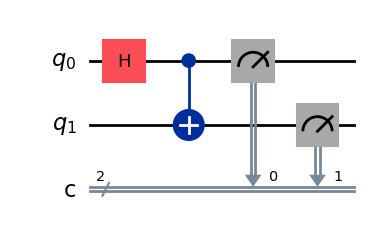

In [16]:
qasm3_string_for_import = '''
OPENQASM 3.0;
include "stdgates.inc";
qubit[2] q;
bit[2] c;
h q[0];
cx q[0], q[1];
c = measure q;
'''
# Your code here
# 1. Convert the OpenQASM 3 string into a Qiskit QuantumCircuit object
qc_from_qasm = qiskit.qasm3.loads(qasm3_string_for_import)

# 2. Draw the circuit using matplotlib
qc_from_qasm.draw(output="mpl")


## 18. Qiskit IBM Runtime API

**Explanation:** Modern quantum applications often need to integrate quantum computations into broader software workflows. IBM Quantum provides cloud-based services that can be accessed programmatically from various programming environments beyond Python. Proper authentication credentials are required to access these services.

**Exercise 18:** This is a conceptual question. You are building a web application backend using Node.js, Go, or another non-Python language, and you need to submit quantum jobs to IBM's quantum computers. What approach would you use to access IBM's quantum computing services programmatically, and what is the most important piece of information you would need to authenticate your requests?

To interact with IBM's quantum computing systems programmatically using a non-Python backend like Node.js, Go, or Java, you would bypass the standard Python Qiskit SDK entirely and connect directly via the [IBM Quantum Compute Service REST API](https://quantum.cloud.ibm.com/docs/api/qiskit-runtime-rest).

### The Approach: REST API Integration
Because you cannot natively run Qiskit libraries, your web application will communicate with IBM's cloud orchestration system over HTTPS:

   1. JSON Payloads: You serialize your quantum circuits into structured intermediate formats (like OpenQASM 3 strings or raw circuit JSON definitions).
   2. HTTP Requests: You make POST requests to IBM's jobs or primitives endpoints to submit the work to the fair-share queue, and track status via GET pooling.

### The Most Important Piece of Authentication Information
The absolute most critical piece of information you need to authenticate your programmatic requests is your unique IBM Quantum API Token (also referred to as your API Key).

* **How it works in the REST API**: Your backend uses this 44-character secret API Key to communicate with the identity provider (e.g., IBM Cloud IAM). The identity provider exchanges that API Key for a short-lived IAM Bearer Token (typically valid for 1 hour).  
* **Header Injection**: This bearer token is passed as an Authorization: Bearer "TOKEN" header in every single raw HTTP request to authorize job deployment.
* **Note**: You will also often pass the Cloud Resource Name (CRN) of your specific backend instance in the request headers to identify which compute plan allocation to bill.

## 19. Running on real IBM Quantum hardware

**Explanation:** In a previous exercise, you used the `Sampler` primitive from `qiskit_ibm_runtime` with the `AerSimulator` local simulator. Here you'll run the `Sampler` primitive on a real IBM Quantum computer.

**Exercise 19:**
Edit the code below in the following way:
1. Comment out the following line:
```
backend = AerSimulator()
```
2. Add the following lines immediately after:
```
service = QiskitRuntimeService(name="fallfest-2025")
backend = service.least_busy(operational=True, simulator=False)
```


In [ ]:
# your_api_key = "deleteThisAndPasteYourAPIKeyHere"
# your_crn = "deleteThisAndPasteYourCRNHere"

# QiskitRuntimeService.save_account(
#     channel="ibm_quantum_platform",
#     token=your_api_key,
#     instance=your_crn,
#     name="fallfest-2025",
# )

# Check that the account has been saved properly
# service = QiskitRuntimeService(name="fallfest-2025")
# print(service.saved_accounts())

# 1. Build the Bell state circuit
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()

# 2. Initialize the local AerSimulator backend
backend = AerSimulator()

# 3. Transpile the circuit for the simulator using a PassManager
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_bell = pm.run(bell)

# 4. Initialize the local Sampler primitive using the simulator backend
sampler = Sampler(backend=backend)

# 5. Run the Sampler locally
job = sampler.run([isa_bell], shots=5000)
result = job.result()

# 6. Retrieve and print the measurement counts
counts = result[0].data.meas.get_counts()
print(f'Measurement counts: {counts}')


Measurement counts: {'11': 2491, '00': 2509}
